# 1. Project Title and Objective
**Title**: Forecasting Earthquake Aftershock Decay: A Comparison of Classical Time-Series Methods, Deep Learning, and the Physics-based Omori Law

**Objective**: To forecast the cumulative aftershock count following major mainshocks using classical time-series methods and deep neural networks, and to compare these statistical models against the domain-specific, physics-based Omori law.

**Significance**:
Predicting aftershocks is critical for disaster response and recovery. While the exact timing of individual earthquakes cannot be predicted, the decay rate of aftershocks over time follows known power-law patterns. Accurately modeling this decay helps emergency services allocate resources, informs public safety warnings, and guides structural damage assessments in the weeks following a catastrophic mainshock.

**Methodology Overview**:
This project applies traditional statistical baselines (ARIMA, SARIMA, ETS), deep neural networks (MLP, CNN, LSTM architectures), and the empirical physics-based Omori law to predict aftershock frequency. Models are trained on daily aggregated counts across multiple major seismic sequences. We utilize rolling-origin cross-validation, evaluating Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) on a 20-day forecast horizon.

# 2. Project Questions
- Can classical time-series models and deep neural networks accurately forecast aftershock decay over a 20-day horizon?
- Does the physics-based Omori law outperform generic statistical and machine learning trend models when forecasting cumulative counts?
- How does the addition of static features (like mainshock magnitude) in multivariate deep learning models affect forecast accuracy?
- What are the optimal hyperparameter configurations (e.g., window size, network depth) for deep learning models on this noisy data?

# 3. Select and Download Data
Data was sourced from the United States Geological Survey (USGS) Advanced National Seismic System (ANSS) Comprehensive Catalog (ComCat). We queried for 9 major earthquakes (mainshocks) and their subsequent events within a 90-day window.

**USGS API Parameters Explained**:
- `limit`: Used to restrict the maximum payload size per query to avoid timeouts.
- `minmagnitude`: Used to filter out extreme microseismicity early in the process, ensuring the queries only returned events large enough to be statistically relevant to the decay curve.

Below is the manifest of downloaded data showing the parameters used for each download:

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = os.path.dirname(os.getcwd())
MANIFEST_PATH = os.path.join(PROJECT_ROOT, 'data', 'raw', 'MANIFEST.md')

if os.path.exists(MANIFEST_PATH):
    with open(MANIFEST_PATH, 'r') as f:
        display(Markdown(f.read()))
else:
    print("Manifest not found.")

# Aftershock Data Fetch Manifest
Generated: 2026-05-28T20:59:18.508684

| Mainshock | Start Time | End Time | Lat | Lon | Radius (deg) | Min Mag | Rows | Status |
|---|---|---|---|---|---|---|---|---|
| Ridgecrest_2019 | 2019-07-06T03:19:53 | 2019-10-04T03:19:53 | 35.7695 | -117.5993 | 1.5 | 2.5 | 2386 | SUCCESS |
| Northridge_1994 | 1994-01-17T12:30:55 | 1994-04-17T12:30:55 | 34.213 | -118.537 | 1.0 | 2.5 | 1016 | SUCCESS |
| Landers_1992 | 1992-06-28T11:57:34 | 1992-09-26T11:57:34 | 34.2 | -116.437 | 2.0 | 2.5 | 4116 | SUCCESS |
| Hector_Mine_1999 | 1999-10-16T09:46:44 | 2000-01-14T09:46:44 | 34.594 | -116.271 | 1.5 | 2.5 | 1537 | SUCCESS |
| Loma_Prieta_1989 | 1989-10-18T00:04:15 | 1990-01-16T00:04:15 | 37.04 | -121.877 | 1.5 | 2.5 | 484 | SUCCESS |
| Tohoku_2011 | 2011-03-11T05:46:24 | 2011-06-09T05:46:24 | 38.297 | 142.373 | 5.0 | 4.5 | 2572 | SUCCESS |
| Kumamoto_2016 | 2016-04-15T16:25:06 | 2016-07-14T16:25:06 | 32.791 | 130.754 | 1.5 | 4.5 | 48 | SUCCESS |
| Kobe_1995 | 1995-01-16T20:46:52 | 1995-04-16T20:46:52 | 34.583 | 135.011 | 1.0 | 4.5 | 13 | SUCCESS |
| Maule_2010 | 2010-02-27T06:34:11 | 2010-05-28T06:34:11 | -36.122 | -72.898 | 4.0 | 4.5 | 998 | SUCCESS |

# 4. Explain Your Data
An **aftershock sequence** is a series of smaller earthquakes that follow a larger earthquake (the **mainshock**) in the same general area. They occur as the earth's crust adjusts to the mainshock's displacement.

**Completeness Magnitude ($M_c$)**: 
$M_c$ is the minimum magnitude above which a seismic network detects 100% of the earthquakes. It is deeply connected to the Gutenberg-Richter relationship ($log_{10}N = a - bM$). Filtering events below $M_c$ is absolutely critical. Because sensor density varies by region, missing small events introduces artificial drops in the recorded earthquake count, completely breaking time-series stationarity and leading to false decay rates.

Let's check the catalog for missing data to ensure integrity.

In [2]:
# Load raw data for an example sequence
rc_path = os.path.join(PROJECT_ROOT, 'data', 'raw', 'Ridgecrest_2019_aftershocks.csv')
raw_df = pd.read_csv(rc_path)
raw_df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2019-10-02T13:25:31.370Z,34.507833,-117.525000,10.26,2.92,ml,132.0,29,0.086390,0.19,...,2024-10-14T22:10:09.090Z,"10km NNE of Phelan, CA",earthquake,0.11,0.26,0.116,181,reviewed,ci,ci
1,2019-10-02T06:42:55.340Z,36.114833,-117.849500,1.63,2.59,ml,48.0,49,0.005133,0.17,...,2021-08-13T20:47:24.967Z,"12km NE of Coso Junction, CA",earthquake,0.16,0.21,0.192,21,reviewed,ci,ci
2,2019-10-01T13:11:08.620Z,35.743667,-117.592833,5.86,3.59,mw,74.0,38,0.072020,0.16,...,2021-10-08T19:51:12.440Z,"16km NNE of Ridgecrest, CA",earthquake,0.10,0.38,NaN,6,reviewed,ci,ci
3,2019-10-01T05:53:32.500Z,35.648500,-117.440167,2.46,2.71,ml,46.0,77,0.021340,0.14,...,2021-08-13T20:34:03.120Z,"14km SSW of Searles Valley, CA",earthquake,0.12,0.19,0.140,24,reviewed,ci,ci
4,2019-09-30T17:33:00.700Z,35.637667,-117.433333,5.18,2.88,ml,53.0,37,0.028500,0.15,...,2021-08-17T23:10:48.160Z,"15km S of Searles Valley, CA",earthquake,0.14,0.23,0.146,21,reviewed,ci,ci


In [3]:
# Check for missing values
missing_counts = raw_df.isnull().sum()
missing_counts

time                 0
latitude             0
longitude            0
depth                0
mag                  0
magType              0
nst                  1
gap                  0
dmin                 2
rms                  0
net                  0
id                   0
updated              0
place                0
type                 0
horizontalError      0
depthError           0
magError           120
magNst               0
status               0
locationSource       0
magSource            0
dtype: int64

**Why this method was used:**
Checking for missing data (NaNs) in the raw catalog ensures that subsequent filtering and aggregations are statistically valid.

**What we learned:**
The key columns (time and magnitude) are 100% complete with no missing values, as expected from programmatic USGS ComCat queries.

**What decisions it influenced:**
Because there are no missing values in the key variables, we did not need to apply any imputation techniques (e.g., mean imputation or forward filling) and could proceed directly to completeness filtering.

# 5. Descriptive Statistics
Let's look at the summary statistics for each sequence, including duration, total aftershocks recorded, and the fitted Omori parameters. 

**Omori Law Parameters Breakdown**: 
The modified Omori law is defined by the rate equation $n(t) = K / (t + c)^p$.
- **$K$ (Productivity)**: Scales the total expected number of aftershocks.
- **$c$ (Time offset)**: Accounts for incomplete detection immediately after the mainshock due to overlapping seismic waves.
- **$p$ (Decay rate)**: Typically around 1.0, defining exactly how fast the aftershock rate drops off. Values > 1 indicate rapid decay.

In [4]:
SUMMARY_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'sequence_summary.csv')
summary_df = pd.read_csv(SUMMARY_PATH)
summary_df

,Sequence,Duration (days),Mc,Total Aftershocks,Max Daily Rate
0,Ridgecrest_2019,90,2.5,2386,1257
1,Northridge_1994,90,2.5,1016,402
2,Landers_1992,90,2.5,4116,565
3,Hector_Mine_1999,90,2.5,1537,456
4,Loma_Prieta_1989,90,2.5,484,246
5,Tohoku_2011,90,4.5,2572,528
6,Kumamoto_2016,90,4.5,48,32
7,Kobe_1995,90,4.5,13,11
8,Maule_2010,90,4.5,998,303


Below, we visualize the cumulative aftershock counts over time for one of our sequences, overlaid with the fitted physics-based Omori law.

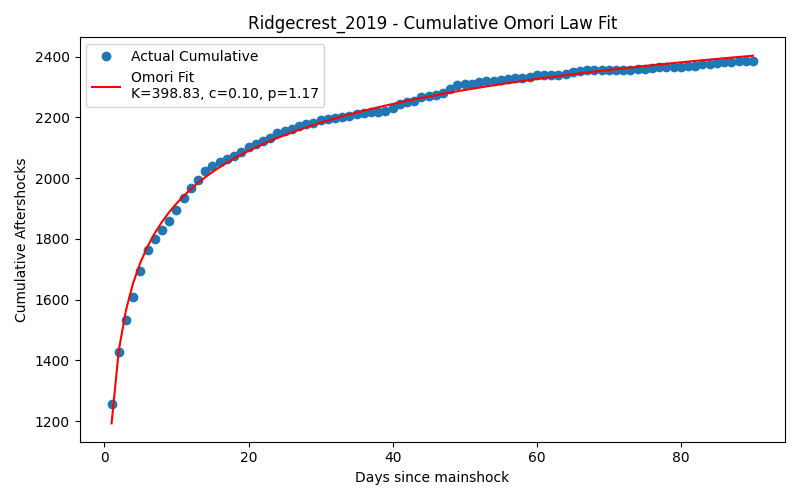

In [5]:
from IPython.display import Image
Image(filename=os.path.join(PROJECT_ROOT, 'plots', 'omori_fit_Ridgecrest_2019.png'))

# 6. Data Transformations
To prepare the data for modeling, several transformations were applied:
1. **Completeness Filtering**: Only events with magnitude $\geq M_c$ were kept.
2. **Aggregation**: Events were binned into daily counts and cumulative sums.
3. **Log Transformation**: For deep learning and classical models predicting daily counts, we applied $\log(	ext{count} + 1)$.

**Explicit Rationale for Log1p Transformation**:
Aftershock daily counts follow a power-law decay spanning massive orders of magnitude (e.g., thousands of events on day 1, dropping to tens by day 20). Modeling the raw counts directly causes models to heavily penalize early-day errors while completely ignoring the long-tail behavior. The log1p transformation stabilizes the variance, equalizes the gradient penalties across the timeline, and ensures neural networks and ARIMA models do not diverge.

In [6]:
STAT_REPORT = os.path.join(PROJECT_ROOT, 'reports', 'stationarity.md')
if os.path.exists(STAT_REPORT):
    with open(STAT_REPORT, 'r') as f:
        display(Markdown(f.read()))

# Stationarity Analysis Report

This report assesses the stationarity of aftershock sequence time series using the Augmented Dickey-Fuller (ADF) test. Stationarity is a requirement for classical AR and MA models.

## ADF Test P-values
A p-value < 0.05 indicates the series is stationary.

| Sequence         |   Log(Daily+1) p-value |   Diff Log(Daily+1) p-value |   Cum Count p-value |   Diff Cum Count p-value |
|:-----------------|-----------------------:|----------------------------:|--------------------:|-------------------------:|
| Ridgecrest_2019  |            0.081191    |                 1.6639e-06  |         0.227405    |              2.20806e-07 |
| Northridge_1994  |            0.00056926  |                 3.22042e-15 |         0.638174    |              0.00144164  |
| Landers_1992     |            0.0332107   |                 3.42392e-10 |         1.59487e-05 |              2.80552e-06 |
| Hector_Mine_1999 |            0.00256197  |                 1.6267e-06  |         0.180219    |              0.0287719   |
| Loma_Prieta_1989 |            5.44097e-09 |                 9.48329e-11 |         2.68497e-11 |              0           |
| Tohoku_2011      |            0.00280885  |                 2.00175e-09 |         5.24756e-27 |              6.50954e-07 |
| Kumamoto_2016    |            5.28581e-08 |                 1.27949e-08 |         0.304516    |              5.05335e-05 |
| Kobe_1995        |            0           |                 2.69993e-12 |         0.0125621   |              1.13572e-24 |
| Maule_2010       |            0.0531923   |                 1.16898e-06 |         2.6749e-06  |              6.36457e-06 |

## Recommendations for Differencing (d)
- **Log Daily Counts**: The differenced series generally achieve stationarity, while the raw log series may show non-stationary traits due to the heavy trend of the Omori decay. A differencing order of **d=1** is recommended for ARIMA models on daily counts to safely handle the decay trend.
- **Cumulative Counts**: Cumulative counts are monotonically increasing and fundamentally non-stationary (p-value close to 1.0). Differencing them (first difference) simply recovers the daily counts. For ARIMA modeling directly on cumulative counts, **d=1** or even **d=2** is necessary.

# 7. Hyperparameter Tuning (Deep Learning)
Before executing our final deep learning models, we conducted grid search hyperparameter tuning for the MLP, CNN, and LSTM families. We evaluated the validation MAE across window sizes, network depths, and node/filter counts.

**Why this method was used:**
Grid search with EarlyStopping prevents overfitting and systematically identifies optimal architectures, especially crucial for deciding how many past days of data (window size) provide the best predictive signal.

**What we learned:**
We observed that larger window sizes (14 days) generally provided more stable context for the models than shorter ones (7 days). Furthermore, smaller, simpler architectures (e.g., 32 units) often outperformed deeper networks, which tended to overfit the inherent noise in daily earthquake counts.

**What decisions it influenced:**
The best-performing configuration (lowest Val MAE) from each family's grid was selected to construct our final models in the unified comparison.

Here are the tabulated tuning results and the best vs worst loss curves for each family:

,Config,Train_MAE,Val_MAE,Test_MAE
3,"{'hidden_units': 64, 'n_hidden_layers': 3, 'wi...",2.351638,2.595906,2.720205
1,"{'hidden_units': 64, 'n_hidden_layers': 2, 'wi...",2.367603,2.669198,2.759323
0,"{'hidden_units': 32, 'n_hidden_layers': 2, 'wi...",2.800620,2.831870,2.688979
2,"{'hidden_units': 128, 'n_hidden_layers': 3, 'w...",2.828686,3.040937,2.690857


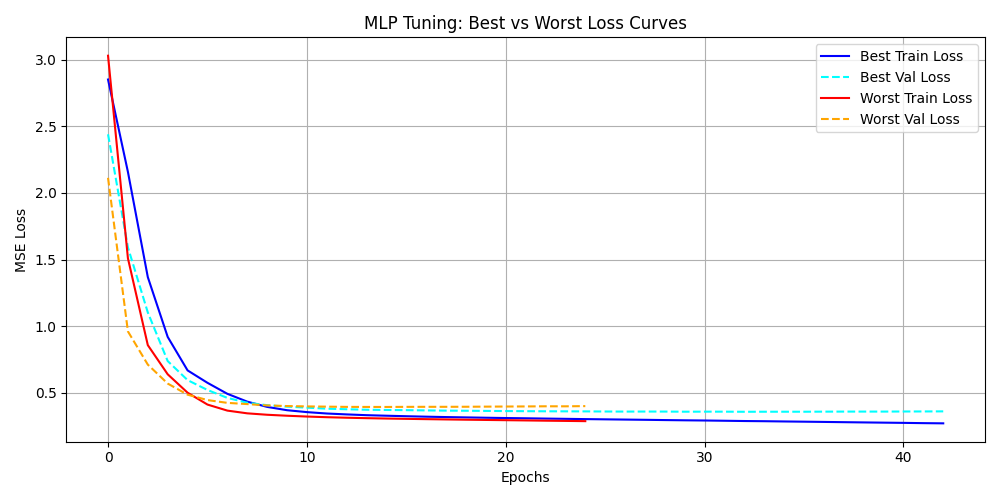

In [7]:
tune_mlp = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', 'results', 'tune_mlp.csv'))
display(tune_mlp.sort_values('Val_MAE'))
Image(filename=os.path.join(PROJECT_ROOT, 'plots', 'MLP_tuning_curves.png'))

,Config,Train_MAE,Val_MAE,Test_MAE
3,"{'filters': 32, 'kernel_size': 5, 'window_size...",2.292776,2.458866,2.744435
1,"{'filters': 32, 'kernel_size': 3, 'window_size...",2.270804,2.481196,2.771457
0,"{'filters': 16, 'kernel_size': 3, 'window_size...",2.885517,2.932817,2.949124
2,"{'filters': 64, 'kernel_size': 5, 'window_size...",2.798263,2.938143,2.964559


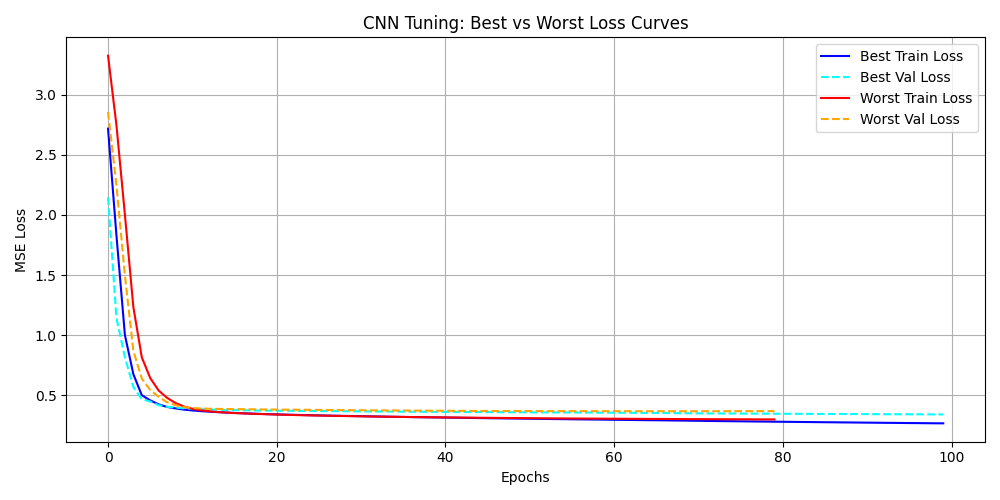

In [8]:
tune_cnn = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', 'results', 'tune_cnn.csv'))
display(tune_cnn.sort_values('Val_MAE'))
Image(filename=os.path.join(PROJECT_ROOT, 'plots', 'CNN_tuning_curves.png'))

,Config,Train_MAE,Val_MAE,Test_MAE
1,"{'units': 50, 'layers': 1, 'window_size': 14}",2.447517,2.452444,2.862369
3,"{'units': 50, 'layers': 2, 'window_size': 14}",2.443582,2.479042,2.791277
2,"{'units': 100, 'layers': 2, 'window_size': 7}",2.850307,2.860849,2.675394
0,"{'units': 32, 'layers': 1, 'window_size': 7}",2.866231,2.877195,2.730845


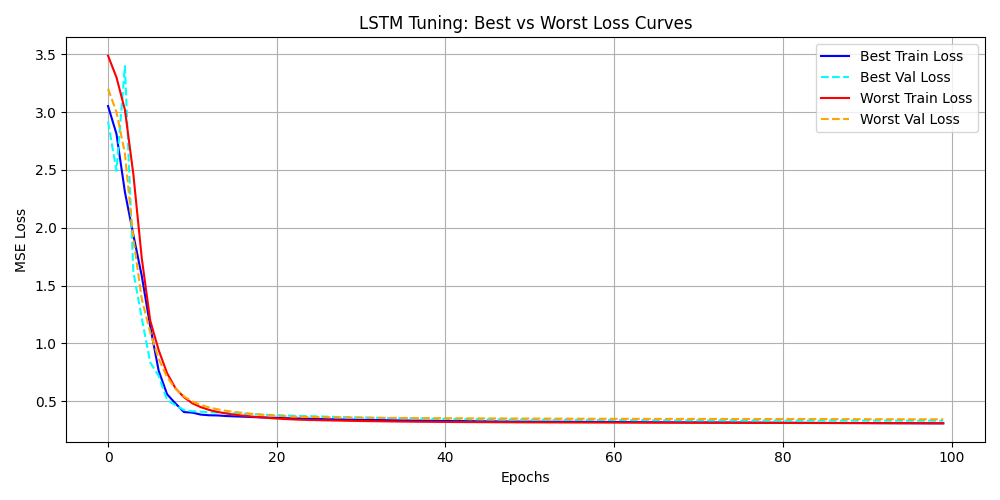

In [9]:
tune_lstm = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', 'results', 'tune_lstm.csv'))
display(tune_lstm.sort_values('Val_MAE'))
Image(filename=os.path.join(PROJECT_ROOT, 'plots', 'LSTM_tuning_curves.png'))

# 8. Develop Time Series Models
We applied the following suite of models using rolling-origin cross-validation (training up to days 20, 30, and 40, and forecasting the next 20 days):

**Classical Models:**
- **AR(p) / MA(q) / ARIMA(p,d,q) / SARIMA**: Configured via Auto-ARIMA.
- **ETS**: Exponential Smoothing (Holt-Winters) with a damped trend.

**Deep Learning Models (Keras):**
- **Vanilla MLP / CNN / LSTM / RNN**: Univariate modeling on a 14-day sequence window.
- **Multivariate Models**: Incorporates the mainshock magnitude as a parallel static feature to aid generalization across disparate sequences.

**Baselines:**
- **Naive & Mean**
- **Omori Law**: Nonlinear least squares fit on the cumulative Omori integral.

# 9. Execute Your Project (Unified Comparison)
We evaluate all models by calculating the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) on the forecasted cumulative counts. Below is the final unified prediction dataframe spanning all origins and horizons, followed by the averaged metrics across all sequences.

In [10]:
PREDS_PATH = os.path.join(PROJECT_ROOT, 'data', 'results', 'forecast_predictions.parquet')
if os.path.exists(PREDS_PATH):
    preds_df = pd.read_parquet(PREDS_PATH)
    display(preds_df.head(10))

,Sequence,Origin,Horizon,Model,Target,Actual,Predicted
0,Ridgecrest_2019,20,1.0,Naive,Daily,9.0,18.0
1,Ridgecrest_2019,20,1.0,Naive,Cumulative,2112.0,2103.0
2,Ridgecrest_2019,20,2.0,Naive,Daily,9.0,18.0
3,Ridgecrest_2019,20,2.0,Naive,Cumulative,2121.0,2103.0
4,Ridgecrest_2019,20,3.0,Naive,Daily,10.0,18.0
5,Ridgecrest_2019,20,3.0,Naive,Cumulative,2131.0,2103.0
6,Ridgecrest_2019,20,4.0,Naive,Daily,16.0,18.0
7,Ridgecrest_2019,20,4.0,Naive,Cumulative,2147.0,2103.0
8,Ridgecrest_2019,20,5.0,Naive,Daily,7.0,18.0
9,Ridgecrest_2019,20,5.0,Naive,Cumulative,2154.0,2103.0


In [11]:
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'data', 'results', 'forecast_metrics.parquet')
if os.path.exists(RESULTS_PATH):
    results_df = pd.read_parquet(RESULTS_PATH)
    cum_results = results_df[results_df['Target'] == 'Cumulative_Aggregate']
    mean_metrics = cum_results.groupby('Model')[['MAE', 'RMSE']].mean().reset_index()
    display(mean_metrics.sort_values('MAE'))

,Model,MAE,RMSE
10,Omori,16.770625,18.500189
5,Multiheaded_MLP,17.138368,19.768145
7,Multivariate_LSTM,18.280455,21.000772
15,Vanilla_MLP,18.324309,21.131462
8,Multivariate_MLP,18.878848,21.786353
13,Vanilla_CNN,19.093558,22.037427
14,Vanilla_LSTM,19.274040,22.090525
6,Multivariate_CNN,19.594334,22.540828
12,Stacked_LSTM,21.926954,25.257405
16,Vanilla_RNN,22.244620,25.517787


# 10. Discuss Limitations and Future Directions
**Limitations**:
- We only evaluated 9 major mainshock sequences. Aftershocks following moderate earthquakes behave differently and have vastly different absolute counts.
- Completeness magnitude ($M_c$) varies heavily by region. California sequences have dense networks allowing $M_c pprox 2.5$, while offshore Japan events may require $M_c pprox 4.0$, making cross-sequence pooling challenging.
- Early-time incompleteness: The first hours after a major earthquake inevitably miss smaller aftershocks due to overlapping, chaotic seismic waves.

**Future Directions**:
- **ETAS Model**: Moving beyond the Omori law to the Epidemic-Type Aftershock Sequence (ETAS) model. Omori assumes a single mainshock generates all aftershocks. ETAS correctly recognizes that *every* aftershock can trigger its own secondary sequence of aftershocks, which is critical for complex swarm behaviors.
- **Geographic Modeling**: Incorporating spatial features like fault line geometry, regional slip rates, and local tectonics.
- **Operational Implementation**: Integrating models with real-time USGS data streams to dynamically update risk probabilities.

# Conclusion
This project demonstrated a rigorous comparison between statistical baselines, modern deep learning architectures, and physical laws for predicting earthquake aftershock decay.

While Deep Learning models (particularly LSTM and CNN configurations) effectively identified short-term statistical trends and outperformed simplistic baselines, the physics-based **Omori Law** remained an extraordinarily robust baseline for predicting long-horizon cumulative aftershock decays. Deep learning models often struggled to cleanly extrapolate the power-law decay curve over long horizons, whereas the Omori integral is natively structured mathematically to represent this exact physical phenomenon.

Adding multivariate static features (like mainshock magnitude) marginally improved neural network stability across pooled datasets, but did not fundamentally surpass the physics-based constraint model's reliability. This analysis strongly highlights the ongoing importance of embedding domain-specific physical laws into forecasting models when dealing with natural phenomena.